In [ ]:
import os
from pathlib import Path

import contextily as cx
import geopandas as gpd
import matplotlib.colors as mcol
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import xyzservices as xyz

from jat_slides.defs.assets.maps.common import (
    add_pop_legend,
    cmap_rdbu,
    get_cmap_bounds,
)

In [2]:
population_grids_path = Path(os.environ["POPULATION_GRIDS_PATH"])

In [3]:
df = (
    gpd.read_file(
        population_grids_path / "final" / "differences" / "2000_2020" / "09.1.01.gpkg",
    )
    .set_index("codigo")
    .assign(
        P_11YMENOS_difference=lambda df: (
            df["pop_difference"] - df["P_12YMAS_difference"]
        ),
    )
)

KeyError: 'pop_difference'

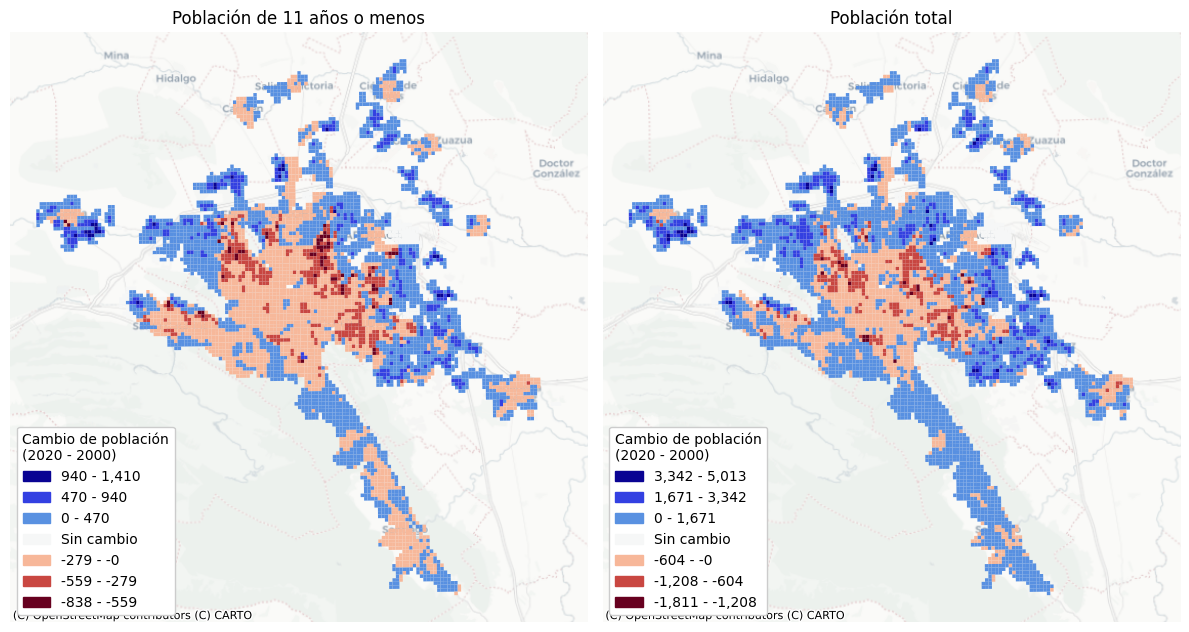

In [ ]:
fig, (axl, axr) = plt.subplots(1, 2, figsize=(12, 8))

for ax, col in zip(
    [axl, axr],
    ["P_11YMENOS_difference", "pop_difference"],
    strict=True,
):
    bounds = get_cmap_bounds(df[col], 3)
    norm = mcol.BoundaryNorm(bounds, 256)

    df.plot(column=col, norm=norm, ax=ax, cmap=cmap_rdbu, ec="k", lw=0, legend=False)
    add_pop_legend(bounds, ax=ax, cmap=cmap_rdbu, legend_pos="lower left")

    ax.axis("off")
    cx.add_basemap(ax, crs=df.crs, source=xyz.providers.CartoDB.Positron, zoom=10)

axl.set_title("Población de 11 años o menos")
axr.set_title("Población total")
fig.tight_layout()
fig.savefig("./fig.jpg", dpi=300, bbox_inches="tight")

In [22]:
temp = (
    df.assign(
        sign_pop=lambda df: np.sign(df["pop_difference"]),
        sign_11ymenos=lambda df: np.sign(df["P_11YMENOS_difference"]),
    )
    .dropna(subset=["sign_pop", "sign_11ymenos"])
    .query("sign_pop != sign_11ymenos")
    .assign(
        pop_gained_11_lost=lambda df: (df["sign_pop"] >= df["sign_11ymenos"]).astype(
            int,
        ),
    )
)

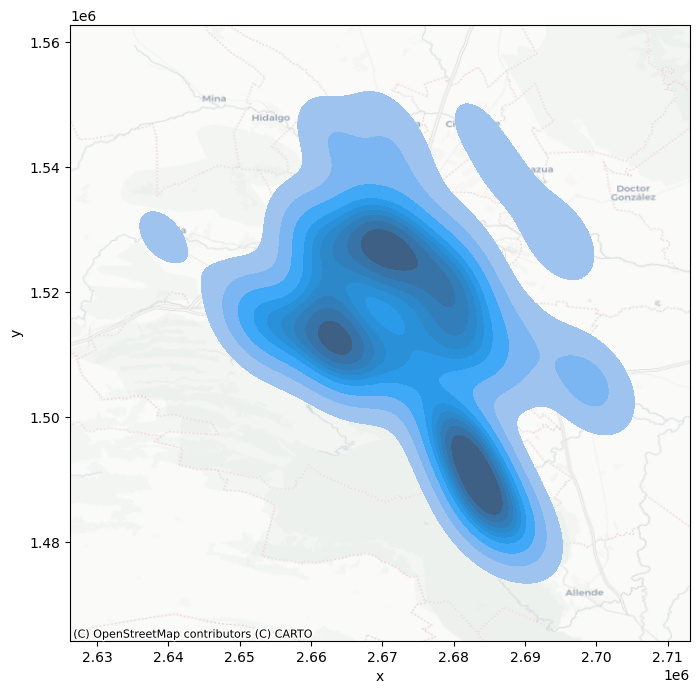

In [ ]:
fig, ax = plt.subplots(figsize=(8, 8))
sns.kdeplot(
    temp.query("pop_gained_11_lost == 1").centroid.get_coordinates(),
    x="x",
    y="y",
    ax=ax,
    fill=True,
)
cx.add_basemap(ax, crs=df.crs, source=xyz.providers.CartoDB.Positron, zoom=10)

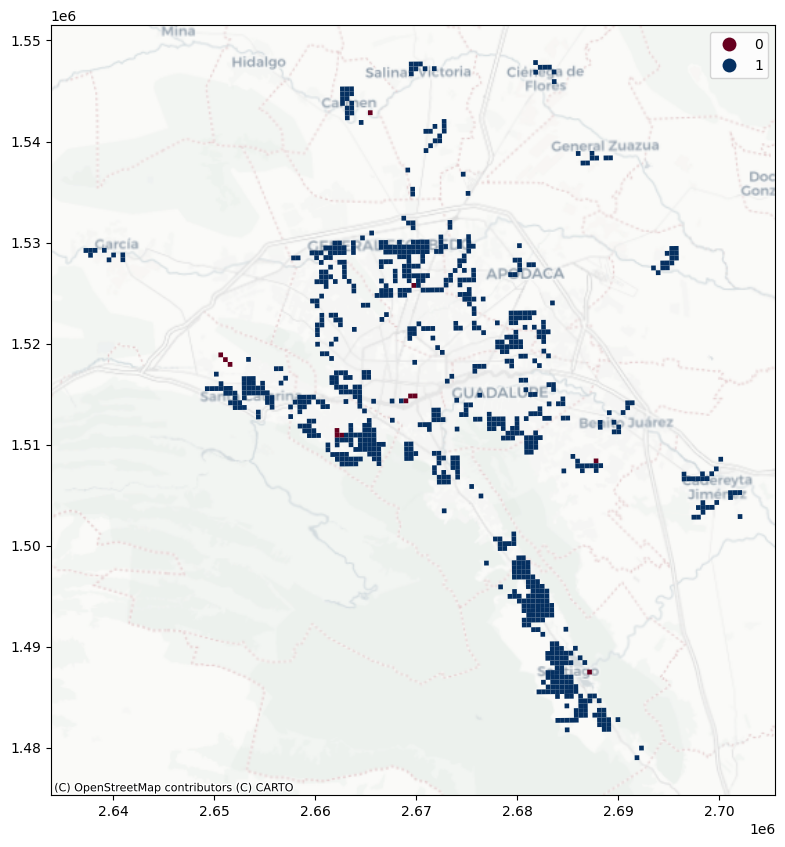

In [ ]:
ax = temp.plot(
    column="pop_gained_11_lost",
    legend=True,
    categorical=True,
    cmap="RdBu",
    figsize=(10, 10),
)
cx.add_basemap(ax, crs=df.crs, source=xyz.providers.CartoDB.Positron, zoom=10)